In [1]:
#Parsing alignment for cluster Ia
from Bio import AlignIO
DruE_align = AlignIO.read("./druantia_zorya/20260304_DruE_DruH_Shannon_enthropy/DruE3_mmseqs98.MUSCLE5.faa", "fasta")
DruH_align = AlignIO.read("./druantia_zorya/20260304_DruE_DruH_Shannon_enthropy/DruH3_mmseqs98.MUSCLE5.faa", "fasta")
#Reference is ECOR19 DruE or WP_020219138.1
#Reference is ECOR19 DruE or WP_133301053.1

def get_reference_sequence(align, ref_prefix):
    RefRecID =""
    RefSeq=""
    for record in align:
        if not record.id.startswith(ref_prefix):
            next
        else:
            RefRecID = record.id
            RefSeq = str(record.seq)
            return RefRecID, RefSeq

DruERefReqID,DruERefSeq = get_reference_sequence(DruE_align, "WP_020219138.1")
DruHRefReqID,DruHRefSeq = get_reference_sequence(DruH_align, "WP_133301053.1")
#print(">" + DruERefReqID + "\n" + DruERefSeq)

In [2]:
#Recalculate Positions to reference
def ref_alignment_to_seq_positions(RefSeq):
    RefAliPosToSeq = {}
    letcount = 0
    
    for element in range(len(RefSeq)):
        if RefSeq[element] != "-":
            RefAliPosToSeq[element] = letcount
            letcount += 1
        else:
            RefAliPosToSeq[element] = -1
            
    return RefAliPosToSeq
###getting it for both Alis
DruERefAliPosToSeq = ref_alignment_to_seq_positions(DruERefSeq)
DruHRefAliPosToSeq = ref_alignment_to_seq_positions(DruHRefSeq)
#testing that it worked
print(dict(list(DruERefAliPosToSeq.items())[0:40]))
print(dict(list(DruHRefAliPosToSeq.items())[1560:1570]))

{0: -1, 1: -1, 2: -1, 3: -1, 4: -1, 5: 0, 6: -1, 7: -1, 8: -1, 9: -1, 10: -1, 11: -1, 12: -1, 13: -1, 14: -1, 15: -1, 16: 1, 17: -1, 18: -1, 19: -1, 20: -1, 21: -1, 22: 2, 23: -1, 24: -1, 25: -1, 26: 3, 27: -1, 28: -1, 29: -1, 30: -1, 31: -1, 32: -1, 33: -1, 34: -1, 35: -1, 36: -1, 37: -1, 38: -1, 39: -1}
{1560: -1, 1561: 62, 1562: 63, 1563: 64, 1564: 65, 1565: 66, 1566: 67, 1567: 68, 1568: -1, 1569: 69}


In [3]:
from pycanal import Canal
import subprocess

def compute_relative_entropy_scores(fastafile, ref_id, verbose=True):
    #get number of reference sequence
    cmd = f'grep ">" {fastafile} | grep -n "{ref_id}" | cut -d":" -f1'
    ref = int(subprocess.check_output(cmd, shell=True, text=True))-1
    #get offset
    
    canal = Canal(
        fastafile=fastafile,   # Multiple sequence alignment
        ref=ref,               # reference sequence position in MSA
        startcount=1, # residue numbering offset
        verbose=verbose
    )

    cons_scores = canal.analysis(include=None, method='relative')
    return cons_scores
###
DruE_cons_scores = compute_relative_entropy_scores("./druantia_zorya/20260304_DruE_DruH_Shannon_enthropy/DruE3_mmseqs98.MUSCLE5.faa","WP_020219138.1")
DruH_cons_scores = compute_relative_entropy_scores("./druantia_zorya/20260304_DruE_DruH_Shannon_enthropy/DruH3_mmseqs98.MUSCLE5.faa","WP_133301053.1")


555 sequences in fasta file

Multiple sequence alignment has 4002 total positions

Reference sequence is WP_020219138.1 MULTISPECIES: DEAD/DEAH box helicase [Enterobacteriaceae]

Reference sequence has 2104 residues (sites) and the first residue is labeled as position 1

Reference sequence residues are labeled as M-1, D-2, V-3, Q-4, Q-5

Calculating amino acid frequencies...
Done.

Calculating conservation scores with relative method...
Done

577 sequences in fasta file

Multiple sequence alignment has 4045 total positions

Reference sequence is WP_133301053.1 STY4851/ECs_5259 family protein [Escherichia coli]

Reference sequence has 1119 residues (sites) and the first residue is labeled as position 1

Reference sequence residues are labeled as M-1, L-2, V-3, K-4, T-5

Calculating amino acid frequencies...
Done.

Calculating conservation scores with relative method...
Done


In [4]:
####Do secondary structure########
from tempfile import gettempdir
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import biotite
import biotite.application.dssp as dssp
import biotite.database.entrez as entrez
import biotite.database.rcsb as rcsb
import biotite.sequence as seq
import biotite.sequence.graphics as graphics
import biotite.sequence.io.genbank as gb
import biotite.structure as struc
import biotite.structure.io.pdb as pdb
import os
import subprocess

# Create 'FeaturePlotter' subclasses
# for drawing the scondary structure features


class HelixPlotter(graphics.FeaturePlotter):
    def __init__(self):
        pass

    # Check whether this class is applicable for drawing a feature
    def matches(self, feature):
        if feature.key == "SecStr":
            if "sec_str_type" in feature.qual:
                if feature.qual["sec_str_type"] == "helix":
                    return True
        return False

    # The drawing function itself
    def draw(self, axes, feature, bbox, loc, style_param):
        # Approx. 1 turn per 3.6 residues to resemble natural helix
        n_turns = np.ceil((loc.last - loc.first + 1) / 4)
        x_val = np.linspace(0, n_turns * 2 * np.pi, 50)
        # Curve ranges from 0.3 to 0.7
        y_val = (-0.4 * np.sin(x_val) + 1) / 2

        # Transform values for correct location in feature map
        x_val *= bbox.width / (n_turns * 2 * np.pi)
        x_val += bbox.x0
        y_val *= bbox.height
        y_val += bbox.y0

        # Draw white background to overlay the guiding line
        background = Rectangle(
            bbox.p0, bbox.width, bbox.height, color="white", linewidth=0
        )
        axes.add_patch(background)
        axes.plot(x_val, y_val, linewidth=2, color='#2b2d83') # '#dd3497')


class SheetPlotter(graphics.FeaturePlotter):
    def __init__(self, head_width=0.8, tail_width=0.5):
        self._head_width = head_width
        self._tail_width = tail_width

    def matches(self, feature):
        if feature.key == "SecStr":
            if "sec_str_type" in feature.qual:
                if feature.qual["sec_str_type"] == "sheet":
                    return True
        return False

    def draw(self, axes, feature, bbox, loc, style_param):
        x = bbox.x0
        y = bbox.y0 + bbox.height / 2
        dx = bbox.width
        dy = 0
        """
        if loc.defect & seq.Location.Defect.MISS_RIGHT:
            # If the feature extends into the prevoius or next line
            # do not draw an arrow head
            draw_head = False
        else:
            draw_head = True
        """
        axes.add_patch(
            biotite.AdaptiveFancyArrow(
                x,
                y,
                dx,
                dy,
                self._tail_width * bbox.height,
                self._head_width * bbox.height,
                # Create head with 90 degrees tip
                head_ratio=0.4,
                draw_head=False,
                color='#fec44f',
                linewidth=0,
            )
        )
######################
## Extract Secondary structure from Predicted AF model
# Converter for the DSSP secondary structure elements
# to the classical ones
dssp_to_abc = {
    "I": "c",
    "S": "c",
    "H": "a",
    "E": "b",
    "G": "c",
    "B": "b",
    "T": "c",
    "C": "c",
}

#Function to deal with DSSP input and vizualize it
def get_annotation(sse, first_id):
    """
    Helper function to convert secondary structure array to annotation.
    """

    def _add_sec_str(annotation, first, last, str_type):
        if str_type == "a":
            str_type = "helix"
        elif str_type == "b":
            str_type = "sheet"
        else:
            # coil
            return
        feature = seq.Feature(
            "SecStr", [seq.Location(first, last)], {"sec_str_type": str_type}
        )
        annotation.add_feature(feature)

    # Find the intervals for each secondary structure element
    # and add to annotation
    annotation = seq.Annotation()
    curr_sse = None
    curr_start = None
    for i in range(len(sse)):
        if curr_start is None:
            curr_start = i
            curr_sse = sse[i]
        else:
            if sse[i] != sse[i - 1]:
                _add_sec_str(
                    annotation, curr_start + first_id, i - 1 + first_id, curr_sse
                )
                curr_start = i
                curr_sse = sse[i]
    # Add last secondary structure element to annotation
    _add_sec_str(annotation, curr_start + first_id, i - 1 + first_id, curr_sse)
    return(annotation)
    
#################run DSSP#####################
!module load DSSP
def plot_sse_from_pdb(
    pdb_path,
    chain_id="A",
    dssp_bin="/usr/local/apps/DSSP/2.3.0/bin/mkdssp",
    figsize=(30, 2)
):
    # Read structure
    pdb_file = pdb.PDBFile.read(pdb_path)
    array = pdb.get_structure(pdb_file, model=1)

    # Keep only amino acids
    mask = struc.filter_amino_acids(array) & (array.chain_id == chain_id)
    protein = array[mask]

    # Run DSSP
    sse = dssp.DsspApp.annotate_sse(protein, bin_path=dssp_bin)
    sse = np.array([dssp_to_abc[e] for e in sse], dtype="U1")

    # Build annotation
    first_id = protein.res_id[0]
    annotation = get_annotation(sse, first_id)

    # Plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    graphics.plot_feature_map(
        ax,
        annotation,
        loc_range=(first_id, first_id + len(sse)),
        show_line_position=True,
        symbols_per_line=len(sse),
        feature_plotters=[HelixPlotter(), SheetPlotter()],
    )

    fig.tight_layout()

    plt.close(fig)   # prevents automatic display in Jupyter
    return fig, annotation, first_id, len(sse)
# Load the structure and plot the secondary structure


[+] Loading DSSP 2.3.0 on cn0010 


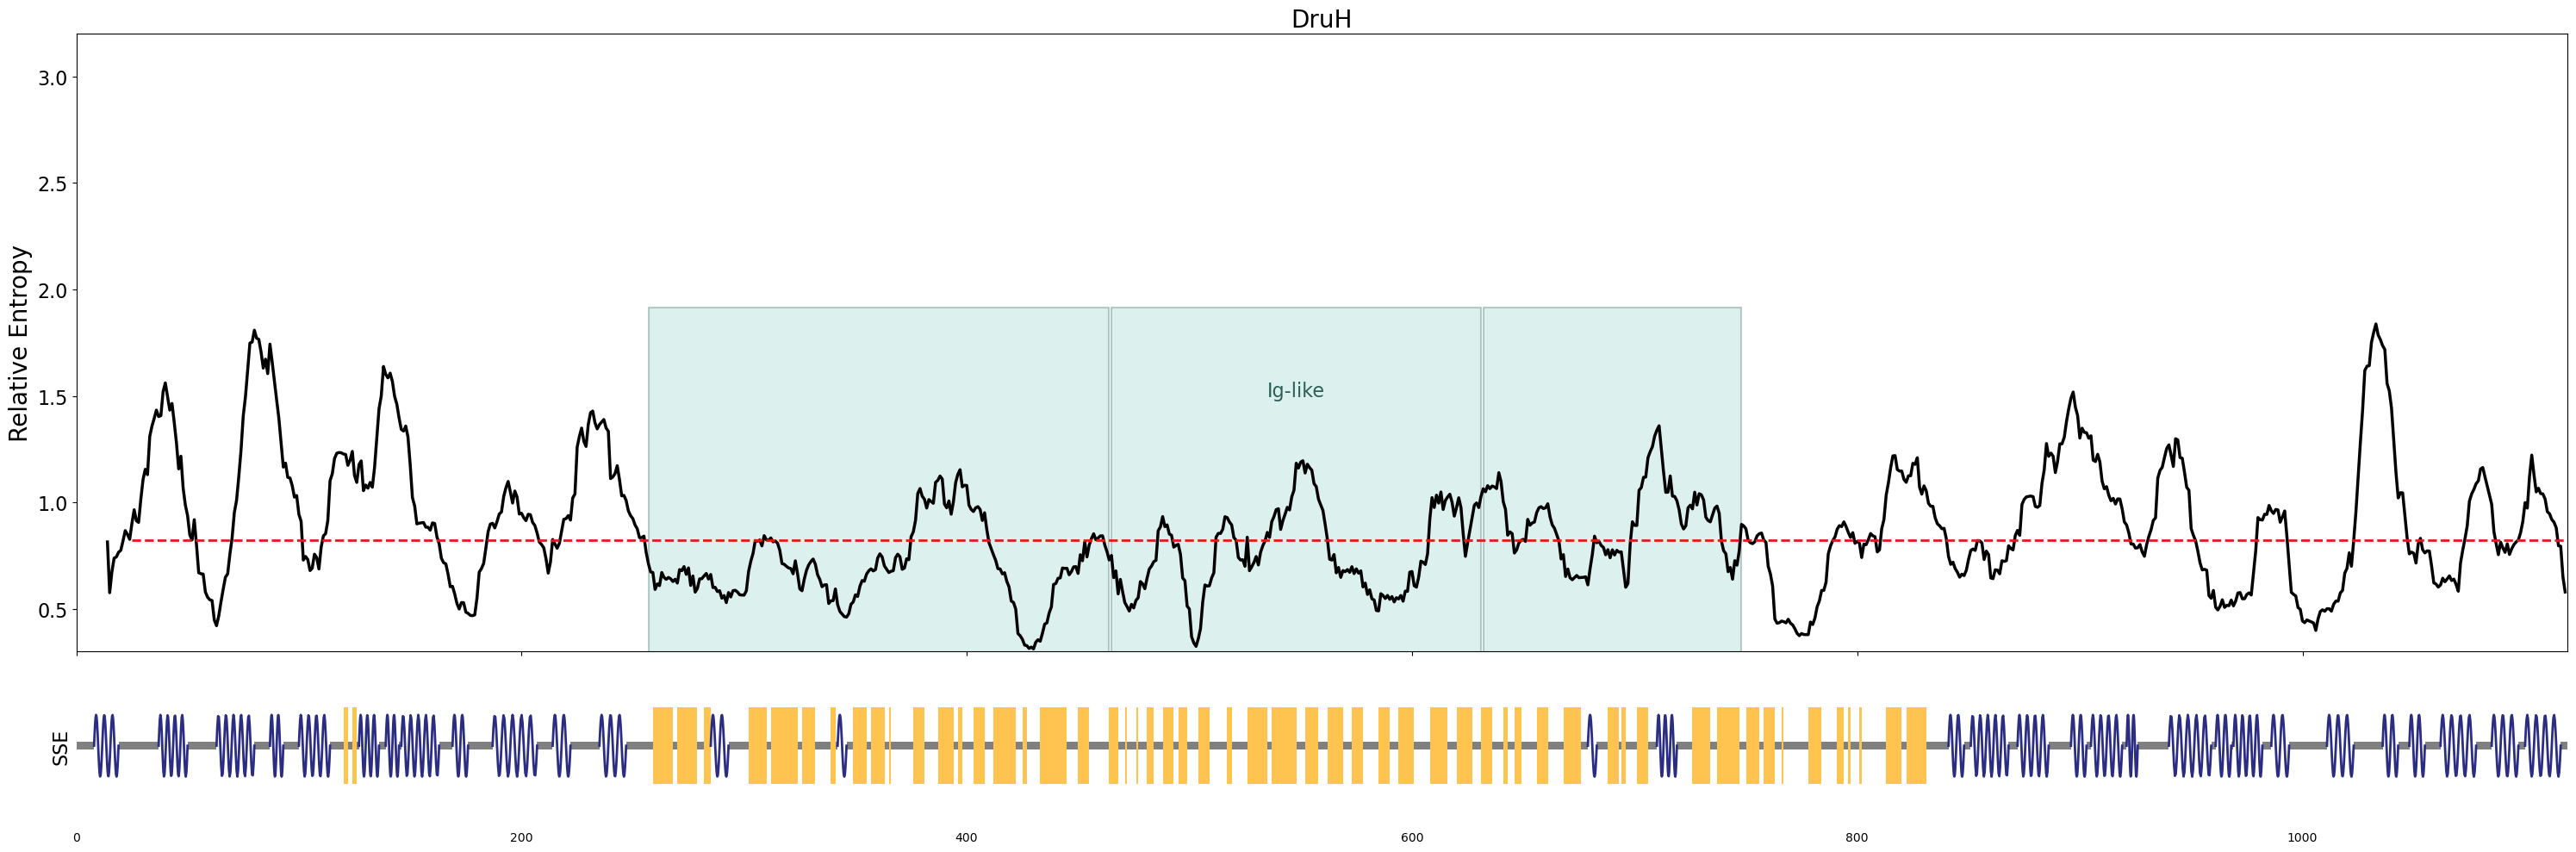

In [12]:
import matplotlib.pylab as plt
import numpy as np
###secondary structure from cryo
DruHSecStr,DruHannot,DruHFirst,DruHLen = plot_sse_from_pdb("druantia_zorya/20260304_DruE_DruH_Shannon_enthropy/ref_models_AF3/druH_ref_AF3_WP_133301053.pdb")

#Draw DruH plot
xvalues = np.arange(DruH_cons_scores.shape[0])
cons_rolling = DruH_cons_scores.rolling(window=15).mean()

# Plot
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(30, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}  # top panel taller
)

# --- Top panel: entropy plot ---
ax1.plot(xvalues, cons_rolling, c='black', lw=2.5)

# median line
ax1.axhline(
    y=np.nanmedian(cons_rolling),
    xmin=25/DruHLen,
    xmax=1,
    color='#e31a1c',
    linestyle='--',
    lw=2
)

# Ig-like regions
for start, end in [(257,464),(465,631),(632,748)]:
    ax1.add_patch(
        plt.Rectangle(
            (start, ax1.get_ylim()[0]),          # bottom-left corner
            end - start,                         # width
            ax1.get_ylim()[1] - ax1.get_ylim()[0], # height
            facecolor='#8dd3c7',alpha=0.3,
            edgecolor='#2c5f56',                  # contour color
            linewidth=1.5
        )
    )

# label for last domain
Igx_middle = (465 + 631)/2
ax1.text(Igx_middle, 1.5, "Ig-like", color='#2c5f56', ha='center', fontsize=16)

ax1.set_ylabel("Relative Entropy", fontsize=20)
ax1.tick_params(axis='both', labelsize=16)
ax1.set_ylim(0.3,3.2)
ax1.set_xlim(0, DruHLen)
ax1.set_title("DruH", fontsize=20)

# --- Bottom panel: secondary structure ---
graphics.plot_feature_map(
    ax2,
    DruHannot,
    loc_range=(DruHFirst, DruHFirst + DruHLen),
    #show_line_position=False,
    symbols_per_line=DruHLen,
    feature_plotters=[HelixPlotter(), SheetPlotter()],
)

ax2.set_ylabel("SSE", fontsize=16)
ax1.tick_params(labelbottom=False)  # top panel: hide labels
ax2.tick_params(labelbottom=True) 

plt.tight_layout()

plt.savefig("druantia_zorya/20260304_DruE_DruH_Shannon_enthropy/DruH_shannon_entropy_20260304.pdf")

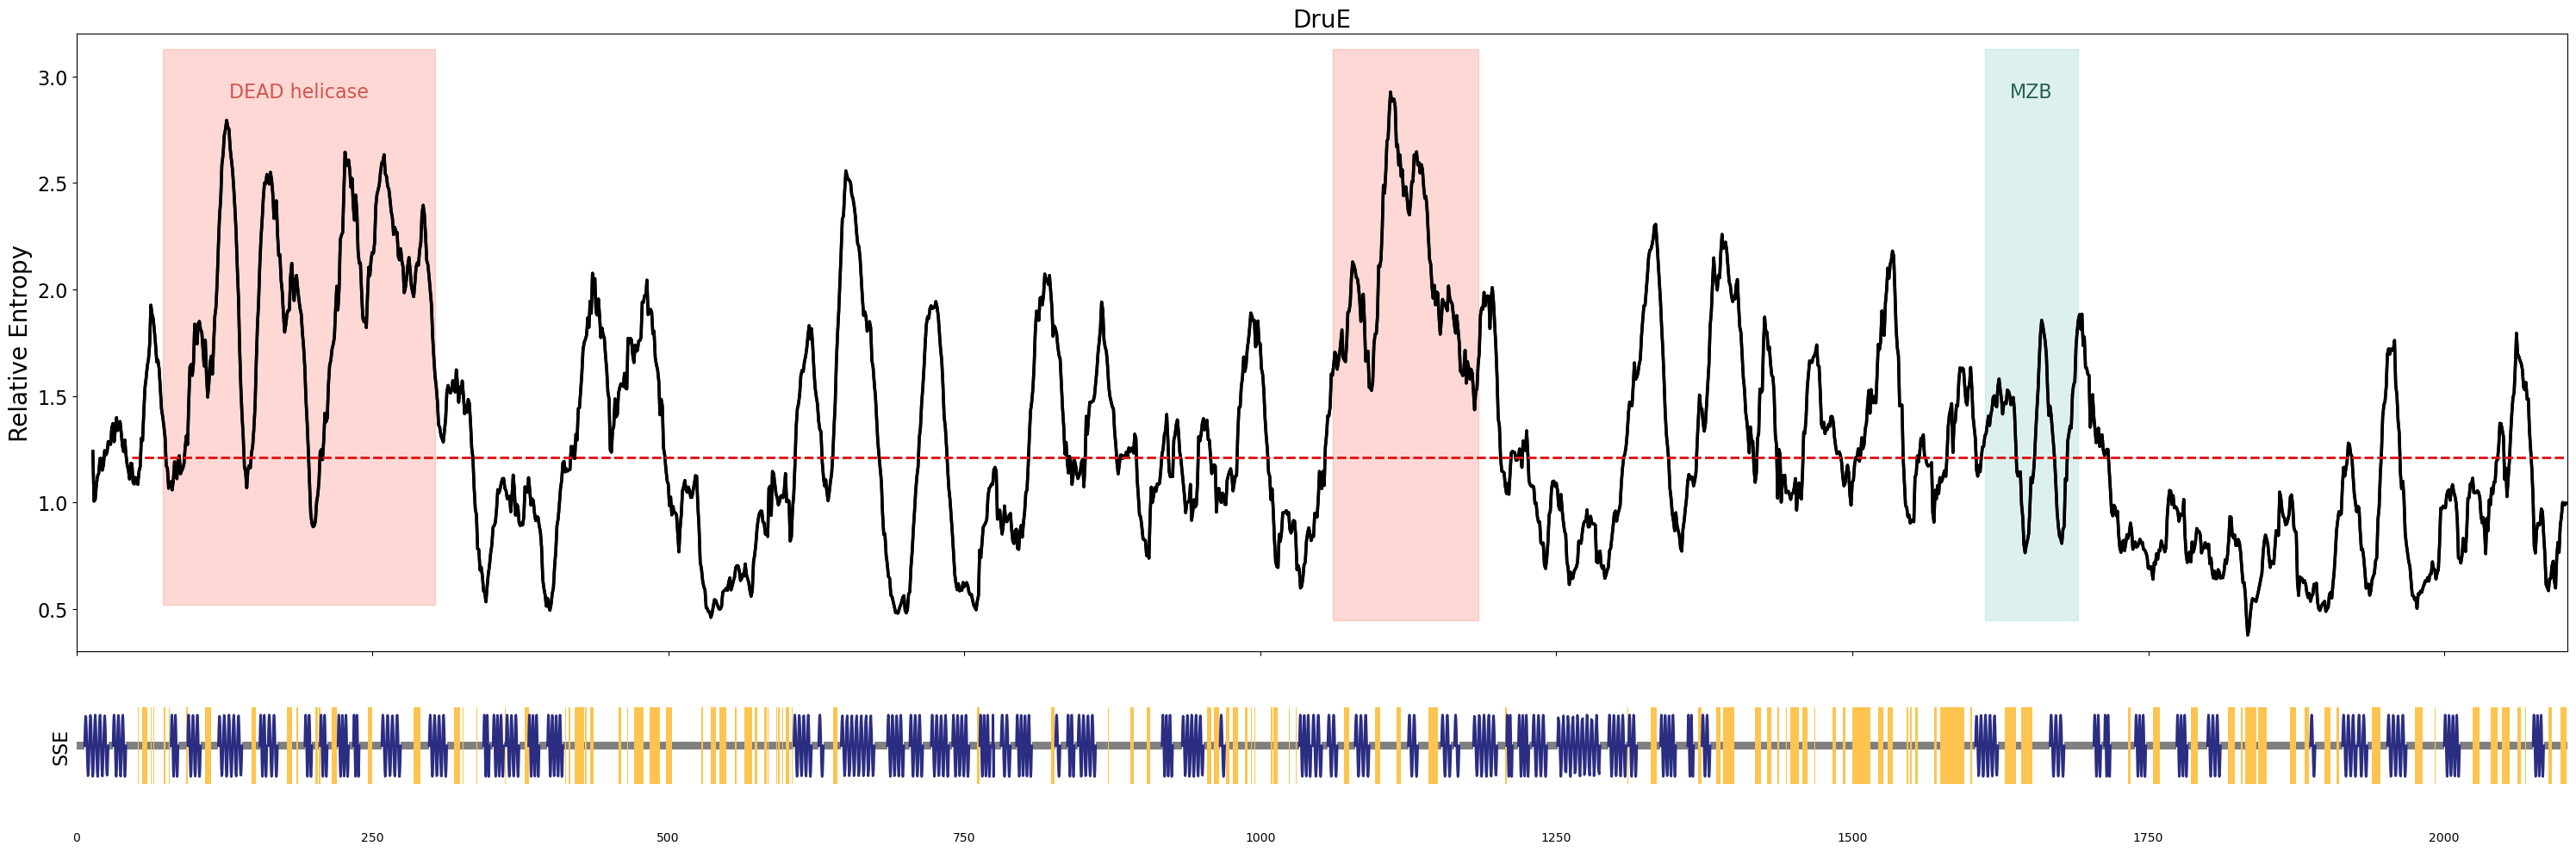

In [6]:
import matplotlib.pylab as plt
import numpy as np
###
DruESecStr,DruEannot,DruEFirst,DruELen = plot_sse_from_pdb("druantia_zorya/20260304_DruE_DruH_Shannon_enthropy/ref_models_AF3/druE_ref_AF3_WP_020219138.pdb")
#Draw DruE plot
xvalues = np.arange(DruE_cons_scores.shape[0])
cons_rolling = DruE_cons_scores.rolling(window=15).mean()
# Plot

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(30, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}  # top panel taller
)

ax1.plot(xvalues, cons_rolling, c='black', lw=2.5)

# median line
ax1.axhline(
    y=np.nanmedian(cons_rolling),
    xmin=25/DruHLen,
    xmax=1,
    color='#e31a1c',
    linestyle='--',
    lw=2
)

ax1.plot(xvalues,cons_rolling, c='black',lw=2.5)
ax1.axhline(y=np.nanmedian(cons_rolling), xmin=35/1273, xmax=1,color='#e31a1c', linestyle='--',lw=2)
ax1.set_ylabel("Relative Entropy",fontsize=20)
ax1.tick_params(axis='both', labelsize=16)
ax1.set_ylim(0.3,3.2)
ax1.set_xlim(0, DruELen)
ax1.set_title("DruE",fontsize=20)
##add domains
ax1.axvspan(73, 303, color='#fb8072', alpha=0.3,ymin=0.15/2, ymax=1.95/2) #DEAD helicase PF00270
DEADx_middle = (73 + 303) / 2
DEADy_position = 2.9
ax1.text(DEADx_middle, DEADy_position, "DEAD helicase", color='#d3544f', ha='center', fontsize=16)
#ax1.axvspan(412, 543, color='#8dd3c7', alpha=0.3,ymin=0.15/2, ymax=1.95/2) #MrfA Zn-binding PF09369
ax1.axvspan(1612, 1691, color='#8dd3c7', alpha=0.3,ymin=0.1/2, ymax=1.95/2) #MrfA Zn-binding (DUF1998) PF09369
Mzbx_middle = (1612 + 1691) / 2
Mzby_position = 2.9
ax1.text(Mzbx_middle, Mzby_position, "MZB", color='#2c5f56', ha='center', fontsize=16)
ax1.axvspan(1061, 1184, color='#fb8072', alpha=0.3,ymin=0.1/2, ymax=1.95/2)#Helicase conserved C-terminal domain

graphics.plot_feature_map(
    ax2,
    DruEannot,
    loc_range=(DruEFirst, DruEFirst + DruELen),
    #show_line_position=False,
    symbols_per_line=DruELen,
    feature_plotters=[HelixPlotter(), SheetPlotter()],
)

ax2.set_ylabel("SSE", fontsize=16)
ax1.tick_params(labelbottom=False)  # top panel: hide labels
ax2.tick_params(labelbottom=True) 

plt.tight_layout()

#plt.show()
plt.savefig("druantia_zorya/20260304_DruE_DruH_Shannon_enthropy/DruE_shannon_entropy_20260304.pdf")